## Data Creation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from models.feedforward_neural_network import FeedForwardNeuralNetwork
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


### Simple Linear Data

$y = 1 + 2x + N(0, 0.5)$

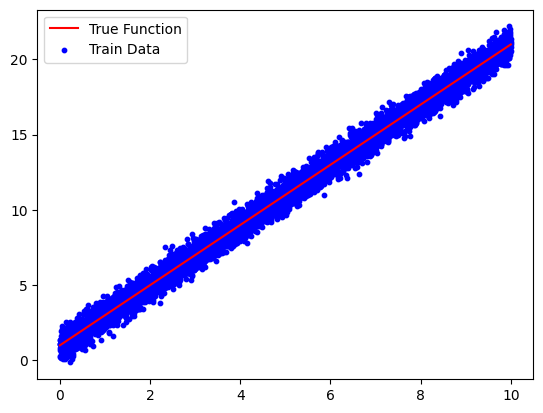

In [2]:
X_lin = np.arange(0, 10, 0.001).reshape(-1, 1)
y_lin = 2*X_lin + 1 + np.random.normal(0, 0.5, X_lin.shape)

X_lin_norm = X_lin
y_lin_norm = y_lin

X_train_lin_norm, X_test_lin_norm, y_train_lin_norm, y_test_lin_norm = train_test_split(X_lin_norm, y_lin_norm, test_size=0.2, random_state=42)

plt.plot(X_lin_norm, 2*X_lin + 1, color = "red", label='True Function')
plt.scatter(X_train_lin_norm, y_train_lin_norm, color='blue', label='Train Data', s=10)
plt.legend()

### Quadratic Data

$y = 1 + 2x_1*x_2 + N(0, 0.5)$

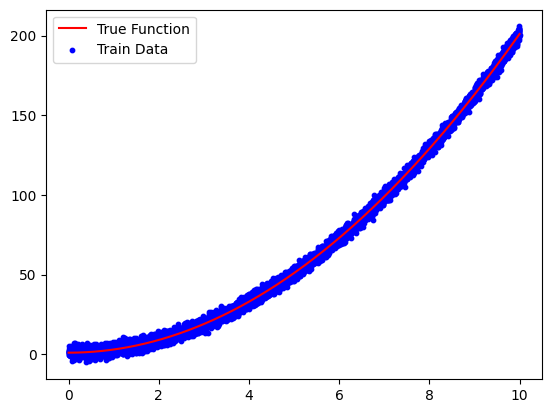

In [3]:
X_quad_1 = np.arange(0, 10, 0.001).reshape(-1, 1)
y_quad = 2*X_quad_1*X_quad_1 + 1 + np.random.normal(0, 2, X_quad_1.shape)

X_quad_1_norm = X_quad_1
y_quad_norm = y_quad

X_train_quad_norm, X_test_quad_norm, y_train_quad_norm, y_test_quad_norm = train_test_split(X_quad_1_norm, y_quad_norm, test_size=0.2, random_state=42)

plt.plot(X_quad_1_norm, 2*X_quad_1*X_quad_1 + 1, color = "red", label='True Function')
plt.scatter(X_train_quad_norm, y_train_quad_norm, color='blue', label='Train Data', s=10)
plt.legend()

In [4]:
FFNN_lin_our = FeedForwardNeuralNetwork([10, 5], epochs=2000, learning_rate=0.001, patience=100, regression=True, verbose=True, auto_save=False).fit(X_train_lin_norm, y_train_lin_norm)
y_pred_lin_our = FFNN_lin_our.predict(X_test_lin_norm)
FFNN_quad_our = FeedForwardNeuralNetwork([5, 10, 15, 15, 10, 5], epochs=2000, learning_rate=0.001, patience=100, regularization_setting=(2, 0.01), regression=True, verbose=True, auto_save=False).fit(X_train_quad_norm, y_train_quad_norm)
y_pred_quad_our = FFNN_quad_our.predict(X_test_quad_norm)

FFNN_lin_skl = MLPRegressor(hidden_layer_sizes=(10, 5), max_iter=2000, learning_rate_init=0.001).fit(X_train_lin_norm, y_train_lin_norm)
y_pred_lin_skl = FFNN_lin_skl.predict(X_test_lin_norm)
FFNN_quad_skl = MLPRegressor(hidden_layer_sizes=(5, 10, 15, 15, 10, 5), max_iter=2000, learning_rate_init=0.001).fit(X_train_quad_norm, y_train_quad_norm)
y_pred_quad_skl = FFNN_quad_skl.predict(X_test_quad_norm)

1254/2000 epochs, Validation loss: 0.252584, Training loss 0.246615. Est. time remaining:         01s
Training stopped at epoch 1255 with best validation loss 0.252534 and best training loss 0.246687 from epoch 1154.
2000/2000 epochs, Validation loss: 4.131615, Training loss 4.286597. Est. time remaining:         00sssss
Training stopped at epoch 2000 with best validation loss 4.114771 and best training loss 4.271434 from epoch 1974.


/home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


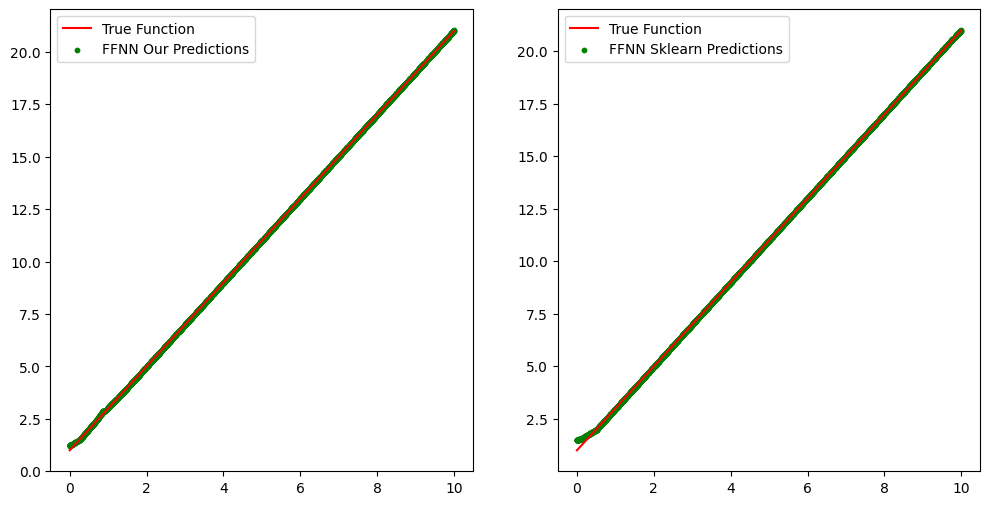

In [5]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(X_lin_norm, (2*X_lin + 1), color = "red", label='True Function')
plt.scatter(X_test_lin_norm, y_pred_lin_our, color='green', label='FFNN Our Predictions', s=10)
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(X_lin_norm, (2*X_lin + 1), color = "red", label='True Function')
plt.scatter(X_test_lin_norm, y_pred_lin_skl, color='green', label='FFNN Sklearn Predictions', s=10)
plt.legend()

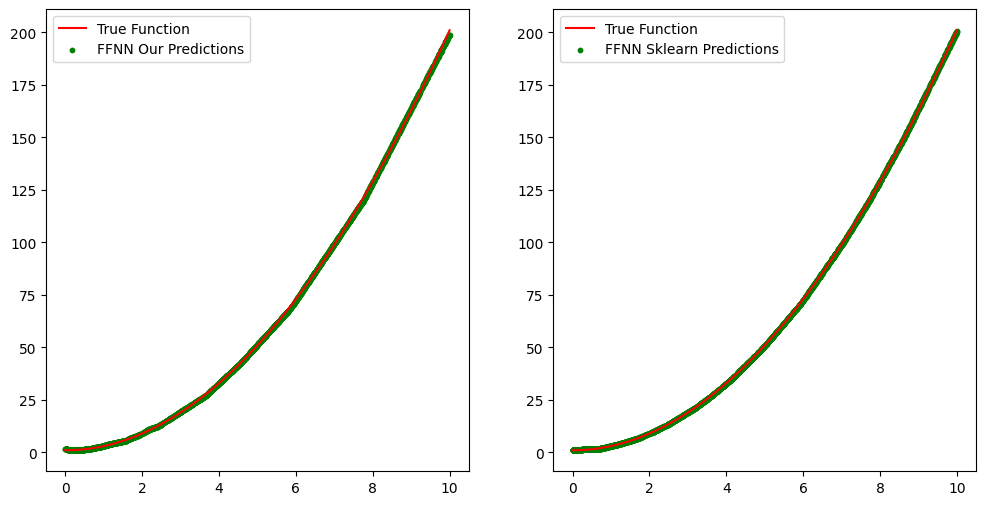

In [6]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(X_quad_1_norm, (2*X_quad_1*X_quad_1 + 1), color = "red", label='True Function')
plt.scatter(X_test_quad_norm, y_pred_quad_our, color='green', label='FFNN Our Predictions', s=10)
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(X_quad_1_norm, (2*X_quad_1*X_quad_1 + 1), color = "red", label='True Function')
plt.scatter(X_test_quad_norm, y_pred_quad_skl, color='green', label='FFNN Sklearn Predictions', s=10)
plt.legend()

In [7]:
def create_data(n_features: int, n_samples: int, poly_expansion: bool, noise_std: float, random_seed: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    if random_seed:
        rng = np.random.RandomState(random_seed)
    else:
        rng = np.random
    X = rng.normal(0, 1, size=(n_samples, n_features))
    
    if poly_expansion:
        X_poly = X.copy()
        for i, deg in enumerate(range(1, n_features + 1)):
            X_poly[:,i] = X[:,i] ** deg
        y_poly = np.sum(X_poly, axis=1, keepdims=True) + rng.normal(0, noise_std, size=(n_samples, 1))
        return X, y_poly
    else:
        y = np.sum(X, axis=1, keepdims=True) + rng.normal(0, noise_std, size=(n_samples, 1))
        return X, y

In [8]:
X, y = create_data(2, 1000, False, 1, 42)

Mean Absolute Difference between Our Model and Sklearn Model Predictions: 78.16541001299767


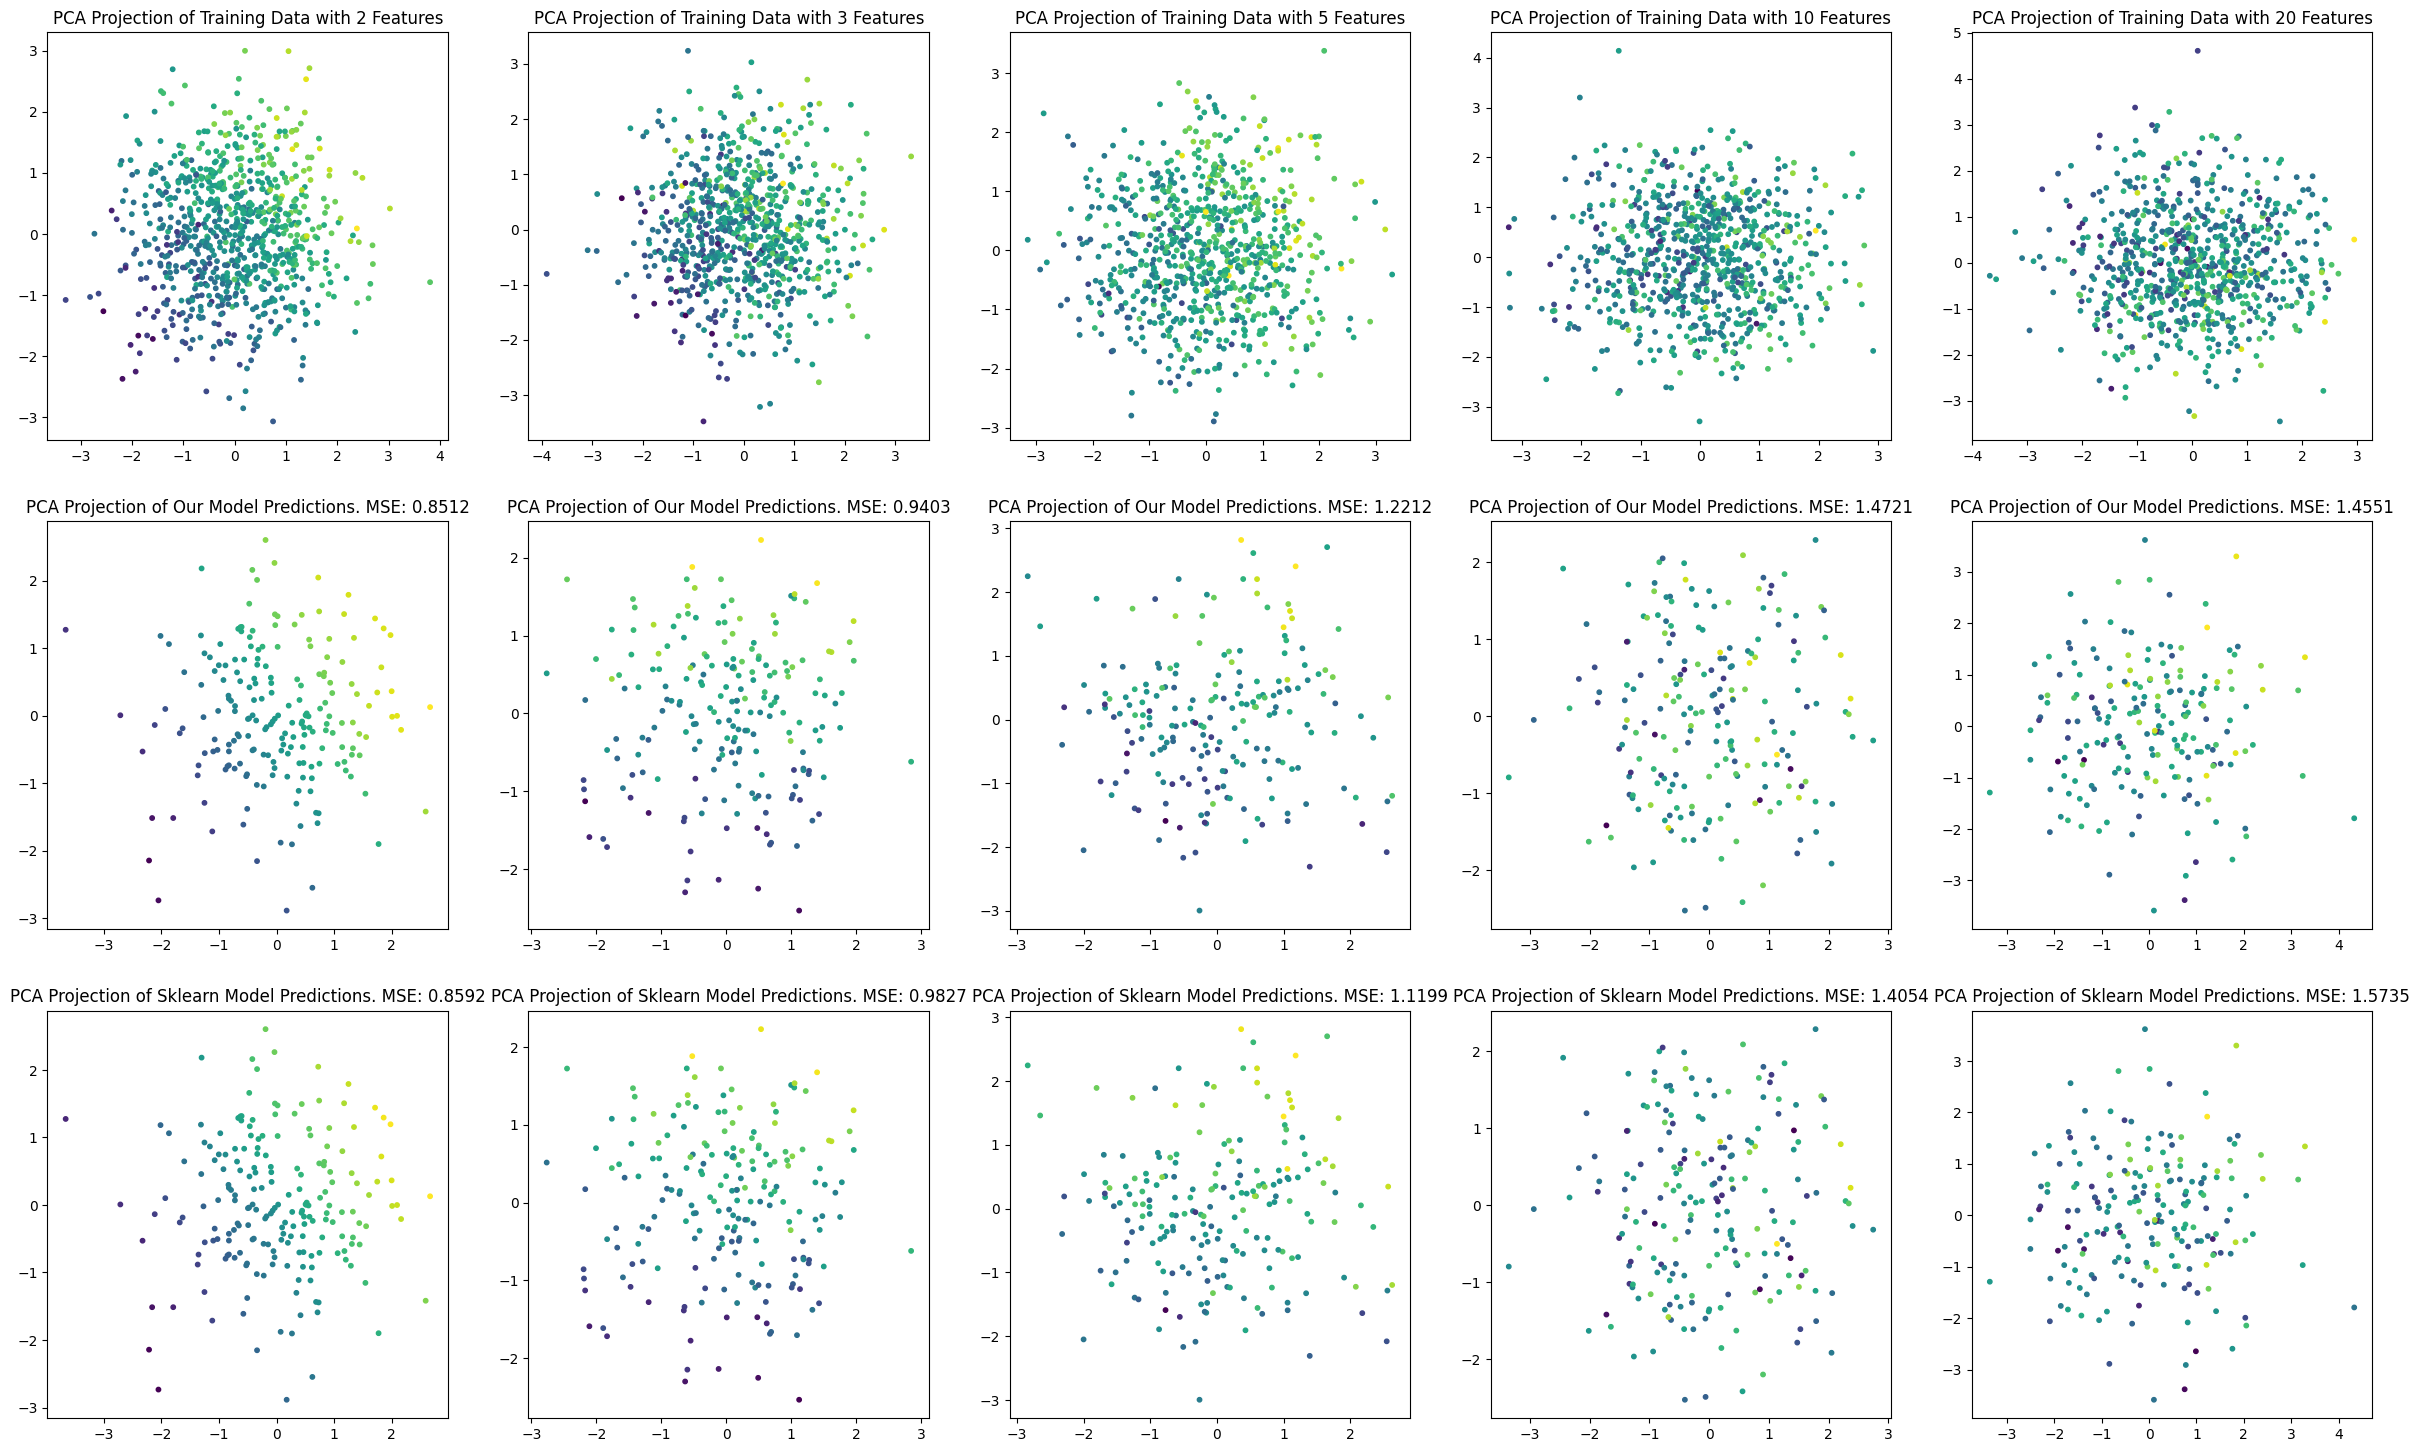

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA

models = [(FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=100, regression=True, auto_save=False),
            MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, alpha=0.001, early_stopping=True)) for _ in range(5)]

n_features_list = [2, 3, 5, 10, 20]
plt.figure(figsize=(6*len(n_features_list), 6*3))

data = [create_data(n_features, 1000, False, 1) for n_features in n_features_list]
data = [train_test_split(X, y, test_size=0.2) for X, y in data]

data_train = [(X_train, y_train) for X_train, _, y_train, _ in data] 
data_test = [(X_test, y_test) for _, X_test, _, y_test in data]

for i, (n_features, (X, y)) in enumerate(zip(n_features_list, data_train)):
    pca = PCA().fit(X)
    X_pca = pca.transform(X)

    plt.subplot(3, len(n_features_list), i + 1)
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y, label=f'Data Points (n_features={n_features})', s=10)
    plt.title(f'PCA Projection of Training Data with {n_features} Features')
    our_model, skl_model = models[i]
    our_model.fit(X, y)
    skl_model.fit(X, y.ravel())
    models[i] = (our_model, skl_model)
    
absolute_differences = []

for i, (n_features, (X, y)) in enumerate(zip(n_features_list, data_test)):
    pca = PCA().fit(X)
    X_pca = pca.transform(X)

    our_model, skl_model = models[i]

    y_pred_our = our_model.predict(X)
    y_pred_skl = skl_model.predict(X)

    absolute_differences.append(np.sum(np.abs(y_pred_our - y_pred_skl)))

    MSE_our = mean_squared_error(y, y_pred_our)
    MSE_skl = mean_squared_error(y, y_pred_skl)

    plt.subplot(3, len(n_features_list), len(n_features_list) + i + 1)
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_our, label=f'Our Model Predictions (n_features={n_features})', s=10)
    plt.title(f'PCA Projection of Our Model Predictions. MSE: {MSE_our:.4f}')
    plt.subplot(3, len(n_features_list), 2*len(n_features_list) + i + 1)
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred_skl, label=f'Sklearn Model Predictions (n_features={n_features})', s=10)
    plt.title(f'PCA Projection of Sklearn Model Predictions. MSE: {MSE_skl:.4f}')
    
mean_absolute_difference = np.mean(absolute_differences)
print("Mean Absolute Difference between Our Model and Sklearn Model Predictions:", mean_absolute_difference)

In [10]:
def get_sine_data(n_samples=100):
    X = np.random.uniform(-np.pi, np.pi, (n_samples, 1))
    y = np.sin(X) + np.random.normal(0, 0.1, (n_samples, 1))
    return X, y, lambda x: np.sin(x)

def get_linear_data(n_samples=100):
    X = np.random.uniform(0, 10, (n_samples, 1))
    y = 2*X + 1 + np.random.normal(0, 0.5, (n_samples, 1))
    return X, y, lambda x: 2*x + 1

def get_quadratic_data(n_samples=100):
    X = np.random.uniform(0, 10, (n_samples, 1))
    y = 2*X*X + 1 + np.random.normal(0, 2, (n_samples, 1))
    return X, y, lambda x: 2*x*x + 1

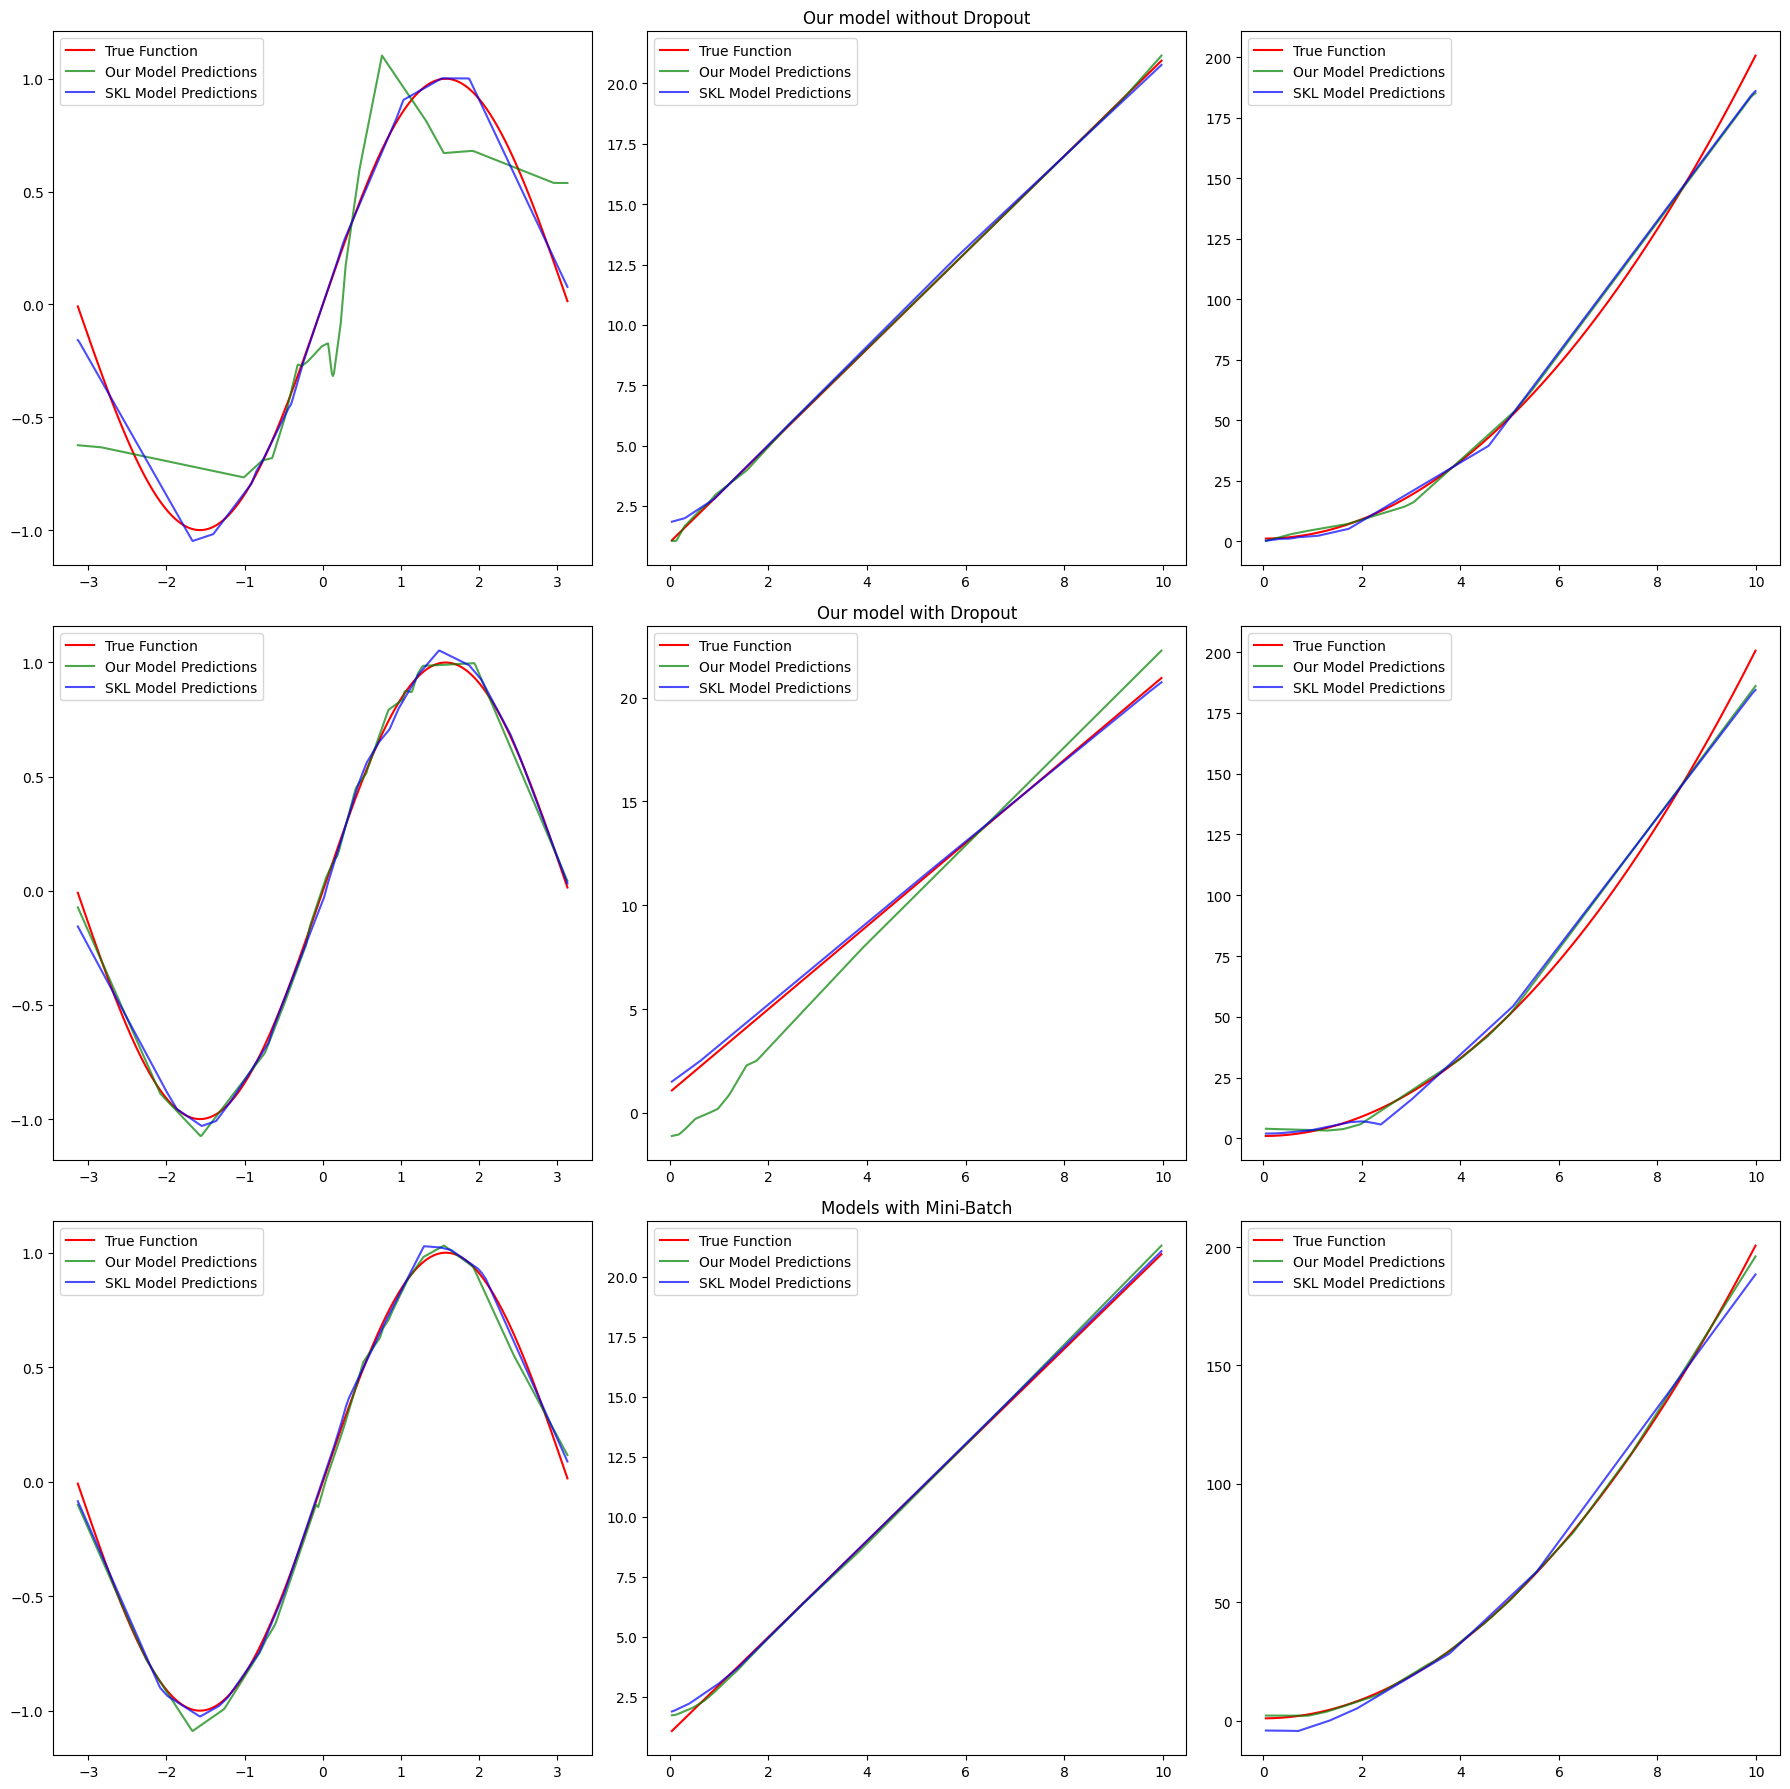

In [17]:
models_withot_dropout = [(FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=10, regression=True, auto_save=False),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, alpha=0.001, early_stopping=True)) for _ in range(3)]

models_with_dropout = [(FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=10, regularization_setting=(2, 0.01), regression=True, auto_save=False),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, alpha=0.001, early_stopping=True)) for _ in range(3)]

models_with_mini_batch = [(FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, patience=10, batch_size=32, regression=True, auto_save=False),
                          MLPRegressor(hidden_layer_sizes=[10, 10, 10], max_iter=1000, alpha=0.001, batch_size=32, early_stopping=True)) for _ in range(3)]

funcs = [get_sine_data, get_linear_data, get_quadratic_data]

plt.figure(figsize=(18, 18))

for i, func in enumerate(funcs):
    X, y, true_function = func(n_samples=500)
    x_base = np.linspace(X.min(), X.max(), 500).flatten()
    random_X = np.random.choice(x_base, size=5)

    our_model, skl_model = models_withot_dropout[i]
    our_model.fit(X, y)
    skl_model.fit(X, y.ravel())
    y_pred_our = our_model.predict(x_base.reshape(-1, 1))
    y_pred_skl = skl_model.predict(x_base.reshape(-1, 1))

    plt.subplot(3, 3, i + 1)
    plt.plot(x_base, true_function(x_base), color='red', label='True Function')
    plt.plot(x_base, y_pred_our, color='green', label='Our Model Predictions', alpha=0.7)
    plt.plot(x_base, y_pred_skl, color='blue', label='SKL Model Predictions', alpha=0.7)
    if i == 1:
        plt.title('Our model without Dropout')
    plt.legend()

    our_model, skl_model = models_with_dropout[i]
    our_model.fit(X, y)
    skl_model.fit(X, y.ravel())
    y_pred_our = our_model.predict(x_base.reshape(-1, 1))
    y_pred_skl = skl_model.predict(x_base.reshape(-1, 1))

    plt.subplot(3, 3, i + 4)
    plt.plot(x_base, true_function(x_base), color='red', label='True Function')
    plt.plot(x_base, y_pred_our, color='green', label='Our Model Predictions', alpha=0.7)
    plt.plot(x_base, y_pred_skl, color='blue', label='SKL Model Predictions', alpha=0.7)
    if i == 1:
        plt.title('Our model with Dropout')
    plt.legend()
    plt.tight_layout()

    our_model, skl_model = models_with_mini_batch[i]
    our_model.fit(X, y)
    skl_model.fit(X, y.ravel())
    y_pred_our = our_model.predict(x_base.reshape(-1, 1))
    y_pred_skl = skl_model.predict(x_base.reshape(-1, 1))

    plt.subplot(3, 3, i + 7)
    plt.plot(x_base, true_function(x_base), color='red', label='True Function')
    plt.plot(x_base, y_pred_our, color='green', label='Our Model Predictions', alpha=0.7)
    plt.plot(x_base, y_pred_skl, color='blue', label='SKL Model Predictions', alpha=0.7)
    if i == 1:
        plt.title('Models with Mini-Batch')
    plt.legend()
    plt.tight_layout()

In [18]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

def compare_to_null_model(model: tuple[str, FeedForwardNeuralNetwork], random_seed: int | None = None) -> None:
    X, y = make_regression(n_samples=1000, n_features=5, noise=0.1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

    model_name, model = model

    null_model = DummyRegressor(strategy="mean")
    null_model.fit(X_train, y_train)
    y_pred_null = null_model.predict(X_test)

    model = model.fit(X_train, y_train)
    y_pred_model = model.predict(X_test)

    mae_null = mean_absolute_error(y_test, y_pred_null)
    mae_model = mean_absolute_error(y_test, y_pred_model)

    print(f"Mean Absolute Error of Null Model: {mae_null:.4f}")
    print(f"Mean Absolute Error of Our '{model_name}' Model: {mae_model:.4f}")
    if mae_model < mae_null:
        print(f"Our '{model_name}' model outperforms the null model.")
    else:
        print(f"Our '{model_name}' model does not outperform the null model.")
    print()

In [19]:
models = [("base",FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, regression=True, auto_save=False)),
          ("with dropout",FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, regularization_setting=(2, 0.01), regression=True, auto_save=False)),
          ("larger",FeedForwardNeuralNetwork([20, 20, 20, 20], epochs=1000, learning_rate=0.001, regression=True, auto_save=False)),
          ("mini batch", FeedForwardNeuralNetwork([10, 10, 10], epochs=1000, learning_rate=0.001, batch_size=32, regression=True, auto_save=False))
          ]

for model in models:
    compare_to_null_model(model)

Mean Absolute Error of Null Model: 120.3080
Mean Absolute Error of Our 'base' Model: 6.9338
Our 'base' model outperforms the null model.

Mean Absolute Error of Null Model: 30.9646
Mean Absolute Error of Our 'with dropout' Model: 1.5026
Our 'with dropout' model outperforms the null model.

Mean Absolute Error of Null Model: 52.0403
Mean Absolute Error of Our 'larger' Model: 1.9355
Our 'larger' model outperforms the null model.

Mean Absolute Error of Null Model: 143.1718
Mean Absolute Error of Our 'mini batch' Model: 0.1189
Our 'mini batch' model outperforms the null model.

